#  Использование одномерных сверток в PyTorch

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html
* https://pytorch.org/docs/stable/generated/torch.nn.MaxPool1d.html#torch.nn.MaxPool1d
* https://wandb.ai/wandb_fc/wb-tutorials/reports/Tutorial-Text-Classification-Using-CNNs--Vmlldzo0NTIxNDI5
* https://machinelearningmastery.com/how-to-develop-convolutional-neural-network-models-for-time-series-forecasting/

## Задачи для совместного разбора

1\. Изучите принцип работы одномерных сверточных слоев в `torch`

![1d conv](https://raw.githubusercontent.com/krzjoa/krzjoa.github.io/master/assets/img/2020-10-03-ts-and-torch-1/conv1d.gif)

![conv1d](https://www.macnica.co.jp/business/ai/blog/files/image5_2.png)

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите данные из файла `ts.csv`. Используя модель, состоящую из одного одномерного сверточного слоя, решите задачу предсказания $y_t$ по `k` предыдущим точкам временного ряда $x_{t-k}...x_{t-1}$. Исследуйте значения $k\in[1, 7]$. Для каждого $k$ выведите на экран итоговое значение функции потерь и веса ядра свертки. Визуализируйте исходный временной ряд и полученные прогнозы.

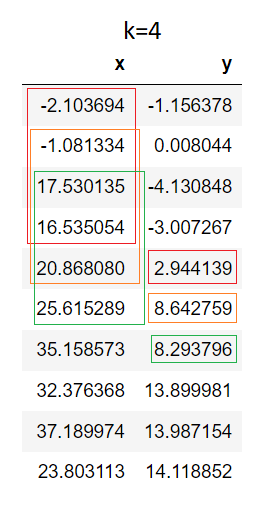
- [ ] Проверено на семинаре

k=1: Loss=0.219323, Kernel weights=[0.6655413]
k=2: Loss=1.124125, Kernel weights=[-0.19426434  0.11191348]
k=3: Loss=0.261063, Kernel weights=[0.38741633 0.17810152 0.39080042]
k=4: Loss=0.407645, Kernel weights=[ 0.02357117 -0.24939615  0.3836746   0.28170428]
k=5: Loss=0.954323, Kernel weights=[-0.02149165 -0.10674002  0.11826826 -0.1218556   0.13312174]
k=6: Loss=0.627464, Kernel weights=[ 0.16910881  0.20041625 -0.10494336 -0.03123218 -0.07122774  0.24849041]
k=7: Loss=0.394105, Kernel weights=[ 0.0168788   0.18197529 -0.06656471  0.2889812  -0.05996139  0.16129531
  0.22155797]


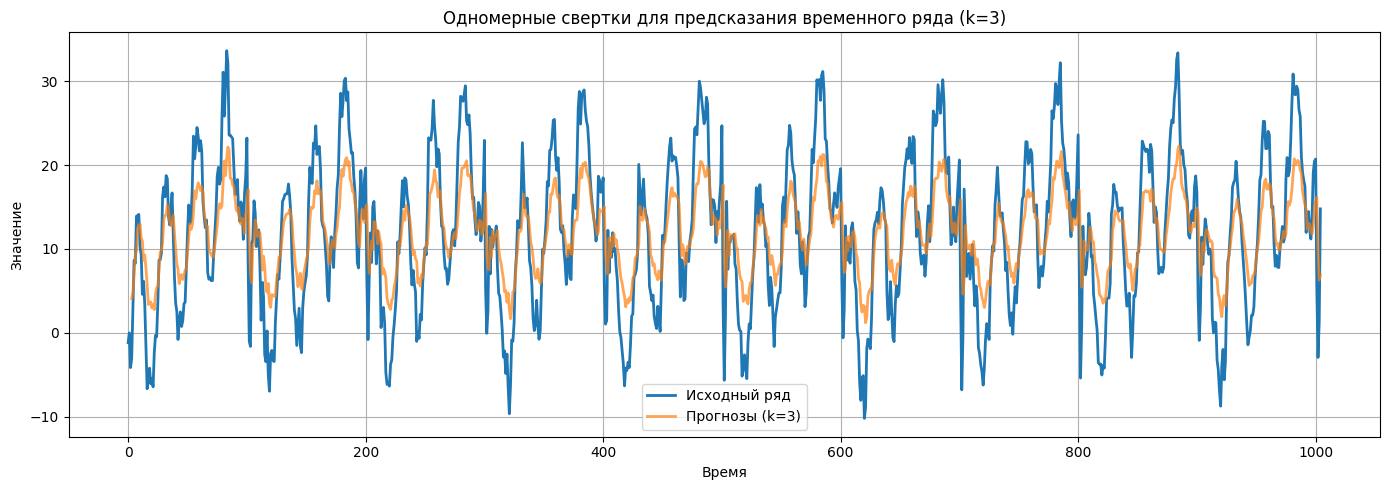

In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Загрузить данные
df = pd.read_csv('data/ts.csv')
data = df['y'].values

# Нормализация данных
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data.reshape(-1, 1)).flatten()

# Исследование k от 1 до 7
for k in range(1, 8):
    # Создание подборок (X, y)
    X, y = [], []
    for i in range(k, len(data_normalized)):
        X.append(data_normalized[i-k:i])
        y.append(data_normalized[i])
    
    X = np.array(X)
    X = torch.FloatTensor(X).unsqueeze(1)  # (N, 1, k) для Conv1d
    y = torch.FloatTensor(y)
    
    # Модель с одной сверткой
    model = nn.Sequential(
        nn.Conv1d(1, 1, kernel_size=k, bias=False),
        nn.Flatten()
    )
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
    
    # Обучение
    for epoch in range(100):
        optimizer.zero_grad()
        output = model(X).squeeze()
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
    
    # Вывод результатов
    weights = model[0].weight.data.numpy().flatten()
    print(f"k={k}: Loss={loss.item():.6f}, Kernel weights={weights}")

# Визуализация прогнозов для k=3
k = 3
X_vis, y_vis = [], []
for i in range(k, len(data_normalized)):
    X_vis.append(data_normalized[i-k:i])
    y_vis.append(data_normalized[i])

X_vis = np.array(X_vis)
X_vis = torch.FloatTensor(X_vis).unsqueeze(1)
y_vis = torch.FloatTensor(y_vis)

# Создание и обучение модели для k=3
model = nn.Sequential(
    nn.Conv1d(1, 1, kernel_size=k, bias=False),
    nn.Flatten()
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

for epoch in range(100):
    optimizer.zero_grad()
    output = model(X_vis).squeeze()
    loss = criterion(output, y_vis)
    loss.backward()
    optimizer.step()

# Прогнозы
with torch.no_grad():
    predictions = model(X_vis).squeeze().numpy()

plt.figure(figsize=(14, 5))
plt.plot(range(len(data)), data, label='Исходный ряд', linewidth=2)
plt.plot(range(k, len(data)), scaler.inverse_transform(predictions.reshape(-1, 1)).flatten(), 
         label=f'Прогнозы (k={k})', alpha=0.7, linewidth=2)
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.title(f'Одномерные свертки для предсказания временного ряда (k={k})')
plt.tight_layout()
plt.show()

<p class="task" id="2"></p>

2\. Загрузите файл `PV_Elec_Gas2.csv`. Опишите класс `ElectricityDataset`, который разбивает данные на окна в соответствии со следующей схемой:

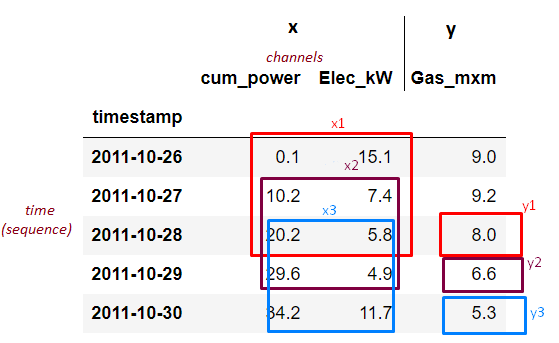

Разбейте набор данных на обучающую и тестовую выборку. Для теста оставьте данные за 2019 год.

- [ ] Проверено на семинаре

In [12]:
# Загрузить данные
df = pd.read_csv('data/PV_Elec_Gas2.csv', index_col=0)
df.index.name = 'Date'

print(df.head())
print(df.info())

# Преобразовать индекс в datetime
df.index = pd.to_datetime(df.index)

# Добавить год
df['Year'] = df.index.year

print("\nРаспределение данных по годам:")
print(df['Year'].value_counts().sort_index())

# Разбить на обучающую и тестовую выборку
train_df = df[df['Year'] != 2019].drop('Year', axis=1)
test_df = df[df['Year'] == 2019].drop('Year', axis=1)

print(f"\nОбучающая выборка: {len(train_df)} строк")
print(f"Тестовая выборка: {len(test_df)} строк")

            cum_power  Elec_kW  Gas_mxm
Date                                   
2011-10-26        0.1     15.1      9.0
2011-10-27       10.2      7.4      9.2
2011-10-28       20.2      5.8      8.0
2011-10-29       29.6      4.9      6.6
2011-10-30       34.2     11.7      5.3
<class 'pandas.core.frame.DataFrame'>
Index: 2948 entries, 2011-10-26 to 2019-11-20
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cum_power  2948 non-null   float64
 1   Elec_kW    2948 non-null   float64
 2   Gas_mxm    2948 non-null   float64
dtypes: float64(3)
memory usage: 92.1+ KB
None

Распределение данных по годам:
Year
2011     67
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    324
Name: count, dtype: int64

Обучающая выборка: 2624 строк
Тестовая выборка: 324 строк


<p class="task" id="3"></p>

3\. Решите задачу предсказания столбца `Gas_mxm` на основе столбцов `cum_power` и `Elec_kW` с использованием одномерных сверток. Для оптимизации используйте мини-пакетный градиентный спуск с использованием `DataLoader`. Обратите внимание, что при создании `DataLoader` вы не можете перемешивать данные.

Постройте график изменения значения функции потерь на обучающем и тестовом множестве в зависимости от номера эпохи. Визуализируйте на одном графике прогнозы модели и предсказываемый временной ряд.

- [ ] Проверено на семинаре

Train dataset size: 2617
Test dataset size: 317
Epoch 10/50, Train Loss: 0.3397, Test Loss: 0.2664
Epoch 20/50, Train Loss: 0.3266, Test Loss: 0.2580
Epoch 30/50, Train Loss: 0.3220, Test Loss: 0.2496
Epoch 40/50, Train Loss: 0.3210, Test Loss: 0.2464
Epoch 50/50, Train Loss: 0.3137, Test Loss: 0.2594


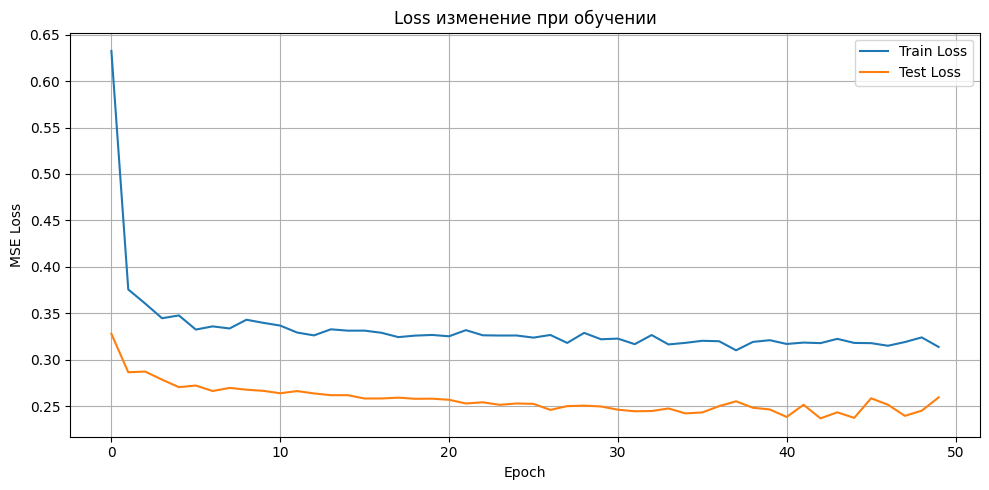

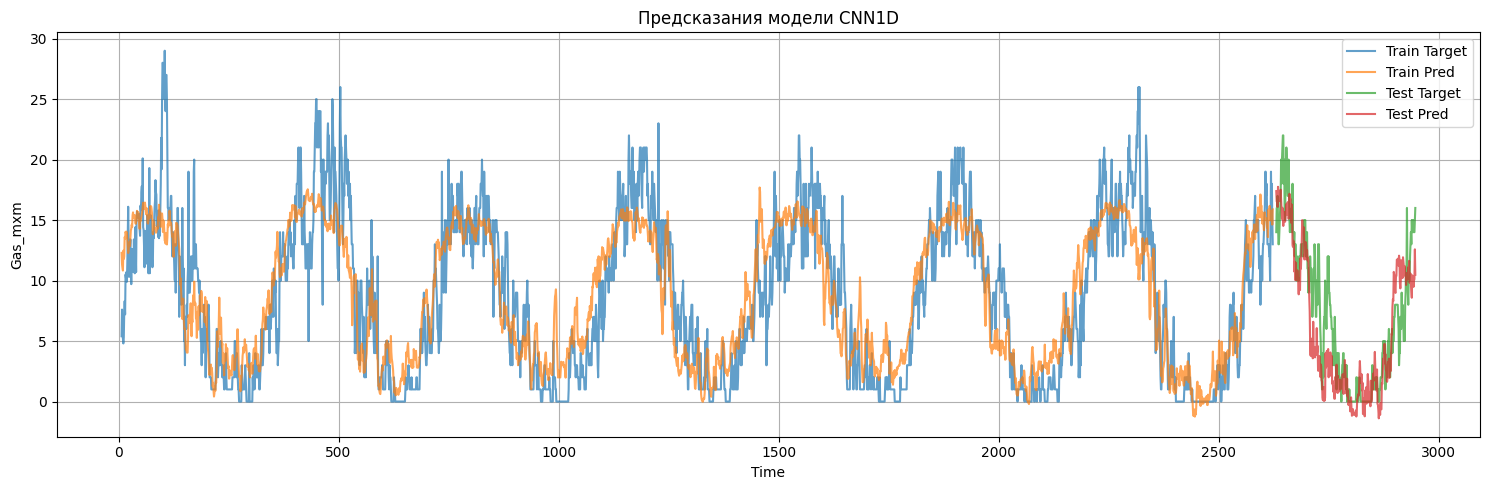

In [13]:
from sklearn.preprocessing import StandardScaler

# Нормализация
scaler = StandardScaler()
train_features = ['cum_power', 'Elec_kW']
target = 'Gas_mxm'

X_train = train_df[train_features].values
y_train = train_df[target].values
X_test = test_df[train_features].values
y_test = test_df[target].values

# Масштабировать
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

# Создать временные окна
def create_windows(X, y, window_size=7):
    X_win, y_win = [], []
    for i in range(window_size, len(X)):
        X_win.append(X[i-window_size:i])
        y_win.append(y[i])
    return np.array(X_win), np.array(y_win)

window_size = 7
X_train_win, y_train_win = create_windows(X_train_scaled, y_train_scaled, window_size)
X_test_win, y_test_win = create_windows(X_test_scaled, y_test_scaled, window_size)

# Dataset класс
class ElectricityDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)  # (N, window_size, num_features)
        self.y = torch.FloatTensor(y)   # (N,)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx].T, self.y[idx]  # Return (num_features, window_size), y

# Создать DataLoader
train_dataset = ElectricityDataset(X_train_win, y_train_win)
test_dataset = ElectricityDataset(X_test_win, y_test_win)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Модель CNN1D
class CNN1DModel(nn.Module):
    def __init__(self, num_features, num_filters=16, kernel_size=3):
        super(CNN1DModel, self).__init__()
        self.conv1 = nn.Conv1d(num_features, num_filters, kernel_size, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2)
        self.fc1 = nn.Linear(num_filters * (window_size // 2), 64)
        self.fc2 = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x.squeeze()

device = torch.device('cpu')
model = CNN1DModel(num_features=2, num_filters=16, kernel_size=3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Обучение
num_epochs = 50
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    # Обучение
    train_loss = 0
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y_batch)
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    # Тестирование
    test_loss = 0
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            test_loss += loss.item() * len(y_batch)
    
    test_loss /= len(test_dataset)
    test_losses.append(test_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

# График losses
plt.figure(figsize=(10, 5))
plt.plot(range(num_epochs), train_losses, label='Train Loss')
plt.plot(range(num_epochs), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.title('Loss изменение при обучении')
plt.tight_layout()
plt.show()

# Прогнозы и визуализация
model.eval()
with torch.no_grad():
    train_pred = []
    for X_batch, _ in train_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch)
        train_pred.extend(y_pred.cpu().numpy())
    
    test_pred = []
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch)
        test_pred.extend(y_pred.cpu().numpy())

# Обратное преобразование
train_pred = y_scaler.inverse_transform(np.array(train_pred).reshape(-1, 1)).flatten()
y_train_win_orig = y_scaler.inverse_transform(y_train_win.reshape(-1, 1)).flatten()
test_pred = y_scaler.inverse_transform(np.array(test_pred).reshape(-1, 1)).flatten()
y_test_win_orig = y_scaler.inverse_transform(y_test_win.reshape(-1, 1)).flatten()

# График прогнозов
plt.figure(figsize=(15, 5))
time_train = range(window_size, len(train_df))[:len(train_pred)]
time_test = range(len(train_df) + window_size, len(train_df) + len(test_df))[:len(test_pred)]

plt.plot(time_train, y_train_win_orig, label='Train Target', alpha=0.7)
plt.plot(time_train, train_pred, label='Train Pred', alpha=0.7)
plt.plot(time_test, y_test_win_orig, label='Test Target', alpha=0.7)
plt.plot(time_test, test_pred, label='Test Pred', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Gas_mxm')
plt.legend()
plt.grid(True)
plt.title('Предсказания модели CNN1D')
plt.tight_layout()
plt.show()

<p class="task" id="4"></p>

4\. Считайте файлы `polarity/positive_reviews.txt` (положительные обзоры на фильмы) и `polarity/negative_reviews.txt` (отрицательные обозоры на фильмы) и разбейте на обучающую и тестовую выборку. Выполните предобработку текста и создайте Vocab на основе обучающей выборки (токен - слово). Выведите на экран количество токенов в полученном словаре. 

Создайте класс `PolarityDataset` и реализуйте метод `__getitem__` таким образом, чтобы он возвращал набор индексов токенов (слов) для текста и метки классов для этих текстов. Создайте два объекта класса `PolarityDataset` для обучающей и тестовой выборки. Выведите на экраны количество элементов и распределение данных по классам в каждом из них.

- [ ] Проверено на семинаре

In [14]:
from torch.utils.data import Dataset
import string
import re

# Загрузить отзывы
with open('data/polarity/positive_reviews.txt', 'r', encoding='utf-8') as f:
    positive_reviews = f.readlines()

with open('data/polarity/negative_reviews.txt', 'r', encoding='utf-8') as f:
    negative_reviews = f.readlines()

print(f"Positive reviews: {len(positive_reviews)}")
print(f"Negative reviews: {len(negative_reviews)}")

# Предобработка текста
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Удалить пунктуацию
    text = re.sub(r'\s+', ' ', text)  # Удалить множественные пробелы
    return text.strip()

# Разбить на обучение и тест
np.random.seed(42)
train_split = 0.8

# Позитивные
pos_indices = np.arange(len(positive_reviews))
np.random.shuffle(pos_indices)
pos_train_idx = pos_indices[:int(len(positive_reviews) * train_split)]
pos_test_idx = pos_indices[int(len(positive_reviews) * train_split):]

# Негативные
neg_indices = np.arange(len(negative_reviews))
np.random.shuffle(neg_indices)
neg_train_idx = neg_indices[:int(len(negative_reviews) * train_split)]
neg_test_idx = neg_indices[int(len(negative_reviews) * train_split):]

# Подготовить данные для обучения
train_texts = ([positive_reviews[i] for i in pos_train_idx] + 
               [negative_reviews[i] for i in neg_train_idx])
train_labels = [1] * len(pos_train_idx) + [0] * len(neg_train_idx)

test_texts = ([positive_reviews[i] for i in pos_test_idx] + 
              [negative_reviews[i] for i in neg_test_idx])
test_labels = [1] * len(pos_test_idx) + [0] * len(neg_test_idx)

# Предобработка
train_texts = [preprocess_text(text) for text in train_texts]
test_texts = [preprocess_text(text) for text in test_texts]

print(f"\nTrain set: {len(train_texts)} ({sum(train_labels)} positive, {len(train_labels) - sum(train_labels)} negative)")
print(f"Test set: {len(test_texts)} ({sum(test_labels)} positive, {len(test_labels) - sum(test_labels)} negative)")

# Создать Vocab
from collections import Counter

vocab = set()
for text in train_texts:
    words = text.split()
    vocab.update(words)

# Сортировать по частотности
word_counts = Counter()
for text in train_texts:
    words = text.split()
    word_counts.update(words)

vocab_list = [word for word, _ in word_counts.most_common()]
word2idx = {word: idx + 1 for idx, word in enumerate(vocab_list)}  # 0 для PAD
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"\nVocab size: {len(word2idx)}")

class PolarityDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=100):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        words = text.split()
        indices = [self.word2idx.get(word, 0) for word in words]
        
        # Padding или truncating
        if len(indices) < self.max_len:
            indices.extend([0] * (self.max_len - len(indices)))
        else:
            indices = indices[:self.max_len]
        
        return torch.LongTensor(indices), torch.LongTensor([label])

# Создать датасеты
train_dataset = PolarityDataset(train_texts, train_labels, word2idx, max_len=100)
test_dataset = PolarityDataset(test_texts, test_labels, word2idx, max_len=100)

print(f"\nTrain dataset: {len(train_dataset)} samples")
print(f"Positive: {sum(train_labels)}, Negative: {len(train_labels) - sum(train_labels)}")

print(f"\nTest dataset: {len(test_dataset)} samples")
print(f"Positive: {sum(test_labels)}, Negative: {len(test_labels) - sum(test_labels)}")

Positive reviews: 5331
Negative reviews: 5331

Train set: 8528 (4264 positive, 4264 negative)
Test set: 2134 (1067 positive, 1067 negative)

Vocab size: 18231

Train dataset: 8528 samples
Positive: 4264, Negative: 4264

Test dataset: 2134 samples
Positive: 1067, Negative: 1067


<p class="task" id="5"></p>

5\. Решите задачу классификации текстов обзоров с использованием одномерных сверток. Для преобразования последовательности индексов в последовательность векторов используйте слой `nn.Embedding`. Обратите внимание, что `nn.Conv1d` ожидает на вход трехмерный тензор размерности `(batch, embedding_dim, seq_len)`. Выведите на экран отчет по классификации для обучающей и тестовой выборки после завершения процесса обучения. Добейтесь accuracy на тестовой выборке не менее 70%.

- [ ] Проверено на семинаре

In [15]:
from sklearn.metrics import classification_report, accuracy_score

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Модель CNN1D для классификации текстов
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, num_filters=100, kernel_sizes=[3, 4, 5]):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, kernel_size)
            for kernel_size in kernel_sizes
        ])
        self.fc = nn.Linear(len(kernel_sizes) * num_filters, 2)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        # x: (batch_size, seq_len)
        x = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        x = x.transpose(1, 2)  # (batch_size, embedding_dim, seq_len)
        
        conv_outputs = []
        for conv in self.convs:
            out = torch.relu(conv(x))  # (batch_size, num_filters, seq_len - kernel_size + 1)
            out = torch.max_pool1d(out, out.size(2))  # (batch_size, num_filters, 1)
            out = out.squeeze(2)  # (batch_size, num_filters)
            conv_outputs.append(out)
        
        x = torch.cat(conv_outputs, 1)  # (batch_size, len(kernel_sizes) * num_filters)
        x = self.dropout(x)
        x = self.fc(x)  # (batch_size, 2)
        return x

device = torch.device('cpu')
model = TextCNN(vocab_size=len(word2idx), embedding_dim=100, num_filters=100, kernel_sizes=[3, 4, 5]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Обучение
num_epochs = 10
for epoch in range(num_epochs):
    # Train
    model.train()
    train_loss = 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.squeeze().to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(labels)
    
    # Test
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for texts, labels in test_loader:
            texts, labels = texts.to(device), labels.squeeze().to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * len(labels)
            
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    accuracy = correct / total
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_dataset):.4f}, "
          f"Test Loss: {test_loss/len(test_dataset):.4f}, Test Accuracy: {accuracy:.4f}")

# Получить прогнозы
model.eval()
train_preds = []
train_true = []
with torch.no_grad():
    for texts, labels in train_loader:
        texts = texts.to(device)
        outputs = model(texts)
        _, predicted = torch.max(outputs, 1)
        train_preds.extend(predicted.cpu().numpy())
        train_true.extend(labels.squeeze().cpu().numpy())

test_preds = []
test_true = []
with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        outputs = model(texts)
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_true.extend(labels.squeeze().cpu().numpy())

# Отчет для обучающей выборки
print("\n=== TRAIN SET ===")
print(classification_report(train_true, train_preds, target_names=['Negative', 'Positive']))
print(f"Accuracy: {accuracy_score(train_true, train_preds):.4f}")

# Отчет для тестовой выборки
print("\n=== TEST SET ===")
print(classification_report(test_true, test_preds, target_names=['Negative', 'Positive']))
print(f"Accuracy: {accuracy_score(test_true, test_preds):.4f}")

Epoch 1/10, Train Loss: 0.7283, Test Loss: 0.6590, Test Accuracy: 0.6157
Epoch 2/10, Train Loss: 0.6145, Test Loss: 0.6213, Test Accuracy: 0.6603
Epoch 3/10, Train Loss: 0.5390, Test Loss: 0.6049, Test Accuracy: 0.6818
Epoch 4/10, Train Loss: 0.4522, Test Loss: 0.6145, Test Accuracy: 0.6739
Epoch 5/10, Train Loss: 0.3851, Test Loss: 0.5974, Test Accuracy: 0.6959
Epoch 6/10, Train Loss: 0.3067, Test Loss: 0.6127, Test Accuracy: 0.7123
Epoch 7/10, Train Loss: 0.2511, Test Loss: 0.6490, Test Accuracy: 0.7193
Epoch 8/10, Train Loss: 0.1990, Test Loss: 0.6732, Test Accuracy: 0.7202
Epoch 9/10, Train Loss: 0.1496, Test Loss: 0.7194, Test Accuracy: 0.7277
Epoch 10/10, Train Loss: 0.1210, Test Loss: 0.7586, Test Accuracy: 0.7334

=== TRAIN SET ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      4264
    Positive       1.00      1.00      1.00      4264

    accuracy                           1.00      8528
   macro avg       1.00      1.0

<p class="task" id="6"></p>

6\. Придумайте небольшой отзыв, прогоните его через модель и выведите метку предсказанного класса (позитивный или негативный). Сделайте это для явно позитивного и явно негативного отзыва.

- [ ] Проверено на семинаре

In [16]:
# Функция для предсказания на новом отзыве
def predict_review(review_text, model, word2idx, device, max_len=100):
    # Предобработка
    review_text = preprocess_text(review_text)
    
    # Преобразование в индексы
    words = review_text.split()
    indices = [word2idx.get(word, 0) for word in words]
    
    # Padding или truncating
    if len(indices) < max_len:
        indices.extend([0] * (max_len - len(indices)))
    else:
        indices = indices[:max_len]
    
    # Преобразование в тензор
    text_tensor = torch.LongTensor([indices]).to(device)
    
    # Предсказание
    model.eval()
    with torch.no_grad():
        output = model(text_tensor)
        probabilities = torch.softmax(output, dim=1)
        prediction = torch.argmax(output, dim=1).item()
        confidence = probabilities[0][prediction].item()
    
    label = "Positive" if prediction == 1 else "Negative"
    return label, confidence

# Позитивный отзыв
positive_review = "This movie is absolutely fantastic! I loved every minute of it. The acting was great, the plot was engaging, and I highly recommend it to everyone!"
label, conf = predict_review(positive_review, model, word2idx, device)
print(f"Review: {positive_review}")
print(f"Prediction: {label}, Confidence: {conf:.4f}\n")

# Негативный отзыв
negative_review = "This movie was terrible and boring. The plot was confusing, the acting was awful, and I wasted my time watching it. Do not watch!"
label, conf = predict_review(negative_review, model, word2idx, device)
print(f"Review: {negative_review}")
print(f"Prediction: {label}, Confidence: {conf:.4f}")

Review: This movie is absolutely fantastic! I loved every minute of it. The acting was great, the plot was engaging, and I highly recommend it to everyone!
Prediction: Positive, Confidence: 0.9427

Review: This movie was terrible and boring. The plot was confusing, the acting was awful, and I wasted my time watching it. Do not watch!
Prediction: Negative, Confidence: 0.9999


## Обратная связь
- [ ] Хочу получить обратную связь по решению